
### Pós-Graduação em Inteligência Artificial e Aprendizado de Máquina  
    Instituição: PUC Minas  
    Disciplina: Python para Ciência de Dados  
    Professor: Leandro Figueira Lessa  
---

### Sobre o Projeto

    Este trabalho foi desenvolvido como parte das atividades da disciplina Python para Ciência de Dados, no curso de Pós-Graduação em Inteligência Artificial e Aprendizado de Máquina da PUC Minas.

    O projeto tem como objetivo realizar uma análise exploratória de dados (EDA) utilizando o dataset **Gapminder**, uma base amplamente utilizada em estudos de desenvolvimento global por reunir indicadores socioeconômicos e demográficos   de  diversos países ao longo de várias décadas.

    A análise busca investigar relações entre indicadores como:

    - Expectativa de vida
    - PIB per capita
    - População
    - Desenvolvimento regional
    - Educação e desenvolvimento humano (dados complementares)

    Por meio de visualizações gráficas e análises estatísticas, este estudo procura identificar padrões históricos, desigualdades regionais e relações entre fatores econômicos, sociais e demográficos que impactam a qualidade de vida das populações ao redor do mundo.

---

### Dataset Utilizado

    O dataset **Gapminder** reúne informações históricas sobre indicadores essenciais de desenvolvimento humano e econômico, cobrindo mais de **140 países** entre 1952 e 2007.

    As principais variáveis analisadas incluem:

    - `lifeExp` → Expectativa de vida
    - `gdpPercap` → PIB per capita
    - `pop` → População total
    - `year` → Ano de referência
    - `continent` → Continente
    - `country` → País

    Como seção complementar, foram integrados dados externos da UNDP (Programa das Nações Unidas para o Desenvolvimento), permitindo enriquecer a análise com indicadores relacionados à educação e desenvolvimento humano.

---
### Alunos

    Matrícula: 1471280  
    Nome: Leon Wagner Farias de Souza  
    Email: 1471280@sga.pucminas.br  

    Matrícula: 1666114  
    Nome: Marcos Silva de Castro  
    Email: 1666114@sga.pucminas.br  

    Matrícula: 1665824  
    Nome: Victor Paiva Nevola  
    Email: 1665824@sga.pucminas.br  

    Matrícula: 1669007  
    Nome: Kelvin de Lucca Feltrin  
    Email: 1669007@sga.pucminas.br  

---

In [ ]:
# Importando as bibliotecas

import sys
import os

# Adiciona a raiz do projeto ao path
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.charts import ChartUtils
from src.utils import prepare_schooling_data

In [6]:
# Funcões para limpeza de dados
def remove_duplicates(df):
    """Remove os dados duplicados do DataFrame."""
    df = df.drop_duplicates()
    return df

# Funções para remover valores nulos
def remove_nulls(df):
    """Remove os valores nulos do DataFrame."""
    df = df.dropna()
    return df   

<font color="#0D9DF0"><h4><b>1 - Coleta, Limpeza e Análise Exploratória (AED)</b></h4></font>

Neste etapa, será realizado a identificação de valores duplicados, valores ausentes.

In [7]:
# Carregando os dados
df_gapminder = pd.read_csv('../data/raw/gapminder_full.csv', sep=',', encoding='utf-8')

In [8]:
# Verificando os dados duplicados
df_gapminder[df_gapminder.duplicated()]

,country,year,pop,continent,lifeExp,gdpPercap
72,Afghanistan,1997,2.222742e+07,Asia,41.763,635.341351
145,Bolivia,1987,6.156369e+06,Americas,57.251,2753.691490
146,Bolivia,1992,6.893451e+06,Americas,59.957,2961.699694
147,Bolivia,1997,7.693188e+06,Americas,62.050,3326.143191
148,Bolivia,2002,8.445134e+06,Americas,63.883,3413.262690
149,Bolivia,2007,9.119152e+06,Americas,65.554,3822.137084
161,Belgium,2007,1.039223e+07,Europe,79.441,33692.605080
207,Burkina Faso,1987,7.586551e+06,Africa,49.557,912.063142
232,Cambodia,1987,8.371791e+06,Asia,53.914,683.895573
345,China,1997,1.230075e+09,Asia,70.426,2289.234136


In [9]:
# Removendo os duplicados
df_gapminder = remove_duplicates(df_gapminder)
df_gapminder.duplicated().sum()

np.int64(0)

In [10]:
# Verificando a existência de valores nulos
df_gapminder.isna().values.any()

df_gapminder.describe()

df_gapminder.head(10)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
5,Afghanistan,1977,14880372.0,Asia,38.438,786.113360
6,Afghanistan,1982,12881816.0,Asia,39.854,978.011439
7,Afghanistan,1987,13867957.0,Asia,40.822,852.395945
8,Afghanistan,1992,16317921.0,Asia,41.674,649.341395
9,Afghanistan,1997,22227415.0,Asia,41.763,635.341351


<font color="#0D9DF0"><h4><b>BLOCO 1 — Desenvolvimento Humano Global</b></h4></font>
<font color="#0D9DF0"><h5><b>1.1 Média da expectativa de vida ao longo dos anos</b></h5></font>
Observa-se crescimento contínuo da expectativa de vida mundial entre 1952 e 2007, indicando avanços significativos nas condições de saúde, saneamento, alimentação e acesso à medicina ao longo das décadas.



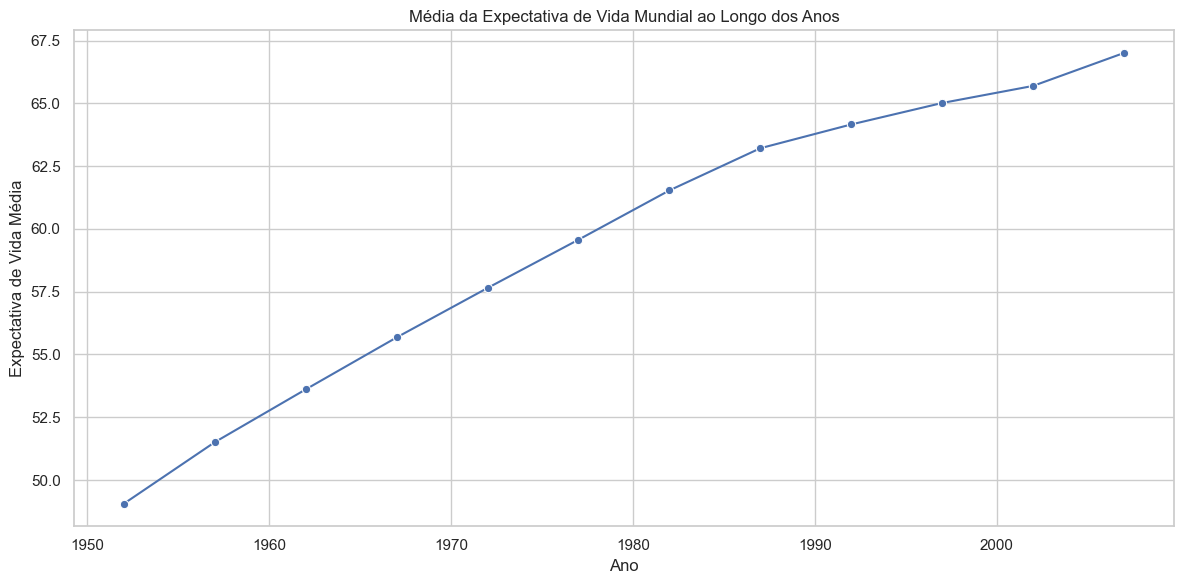

In [11]:
# Calcular média da expectativa de vida por ano
media_vida = df_gapminder.groupby("year", as_index=False)["lifeExp"].mean()
# Exibir resultado
ChartUtils.line_plot(
    data=media_vida,
    x="year",
    y="lifeExp",
    title="Média da Expectativa de Vida Mundial ao Longo dos Anos",
    xlabel="Ano",
    ylabel="Expectativa de Vida Média"
)

<font color="#0D9DF0"><h5><b>1.2 Histograma 1952 vs 2007</b></h5></font>
A distribuição da expectativa de vida desloca-se significativamente para valores mais elevados em 2007 quando comparada a 1952, evidenciando melhora global das condições de vida e saúde da população mundial. 

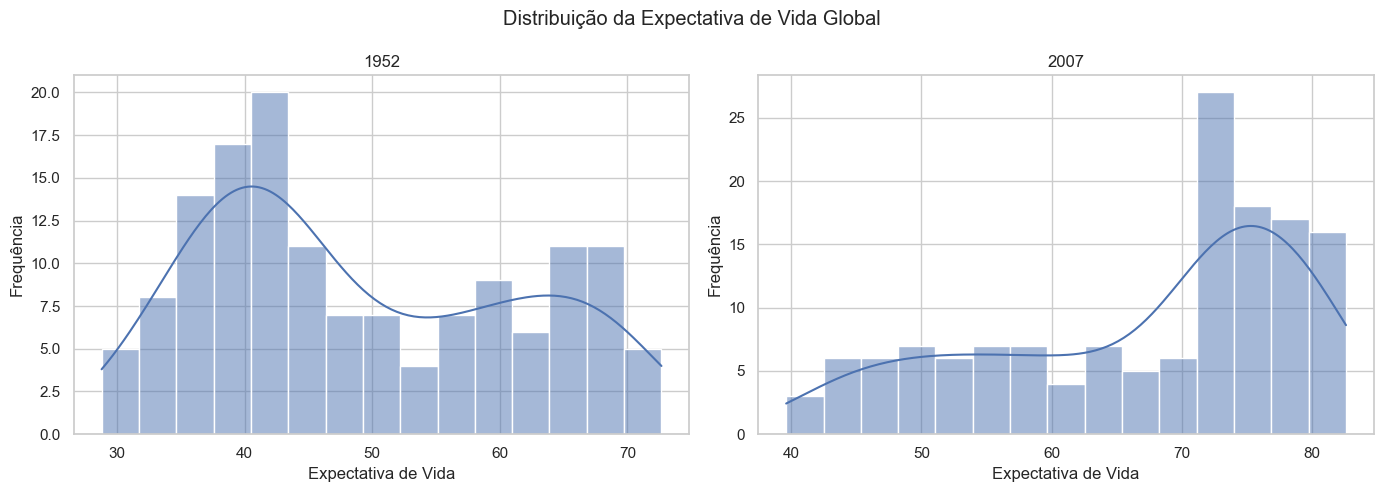

In [12]:
# Filtrar os anos
df_1952 = df_gapminder[df_gapminder["year"] == 1952]
df_2007 = df_gapminder[df_gapminder["year"] == 2007]

ChartUtils.compare_hist_subplot(
    data1=df_1952,
    data2=df_2007,
    x="lifeExp",
    title1="1952",
    title2="2007",
    suptitle="Distribuição da Expectativa de Vida Global",
    xlabel="Expectativa de Vida"
)

<font color="#0D9DF0"><h5><b>1.3 Países acima de 80 anos</b></h5></font>
Os países com expectativa de vida superior a 80 anos em 2007 concentram-se majoritariamente em regiões economicamente desenvolvidas, especialmente Europa, Oceania e partes da Ásia. 

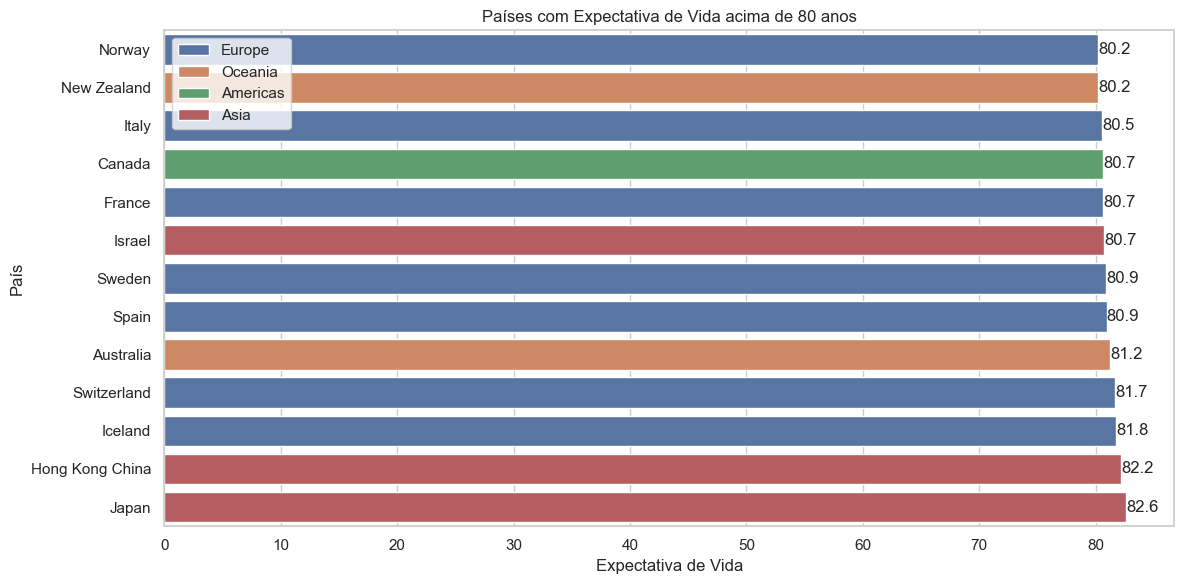

In [13]:
df_80 = df_gapminder[df_gapminder["year"] == 2007]
df_80 = df_80[df_80["lifeExp"] > 80]

# Ordenar valores
df_80 = df_80.sort_values(
    by="lifeExp",
    ascending=True
)

ChartUtils.bar_plot(
    data=df_80,
    x="lifeExp",
    y="country",
    hue="continent",
    title="Países com Expectativa de Vida acima de 80 anos",
    xlabel="Expectativa de Vida",
    ylabel="País",
    value_format="%.1f"
)

<font color="#0D9DF0"><h4><b>BLOCO 2 — Economia e Desenvolvimento</b></h4></font> 
<font color="#0D9DF0"><h5><b>2.1 - PIB vs Expectativa de Vida</b></h5></font> 
Observa-se uma correlação positiva entre PIB per capita e expectativa de vida em 2007. Países com maior riqueza média tendem a apresentar melhores indicadores de longevidade, provavelmente devido ao maior acesso à saúde, alimentação, saneamento e infraestrutura. Entretanto, percebe-se que após determinado nível econômico, o aumento do PIB gera ganhos menores na expectativa de vida.

A escala logarítmica foi aplicada ao PIB per capita devido à grande disparidade econômica entre os países, permitindo melhor distribuição visual dos dados e facilitando a análise da correlação com a expectativa de vida.

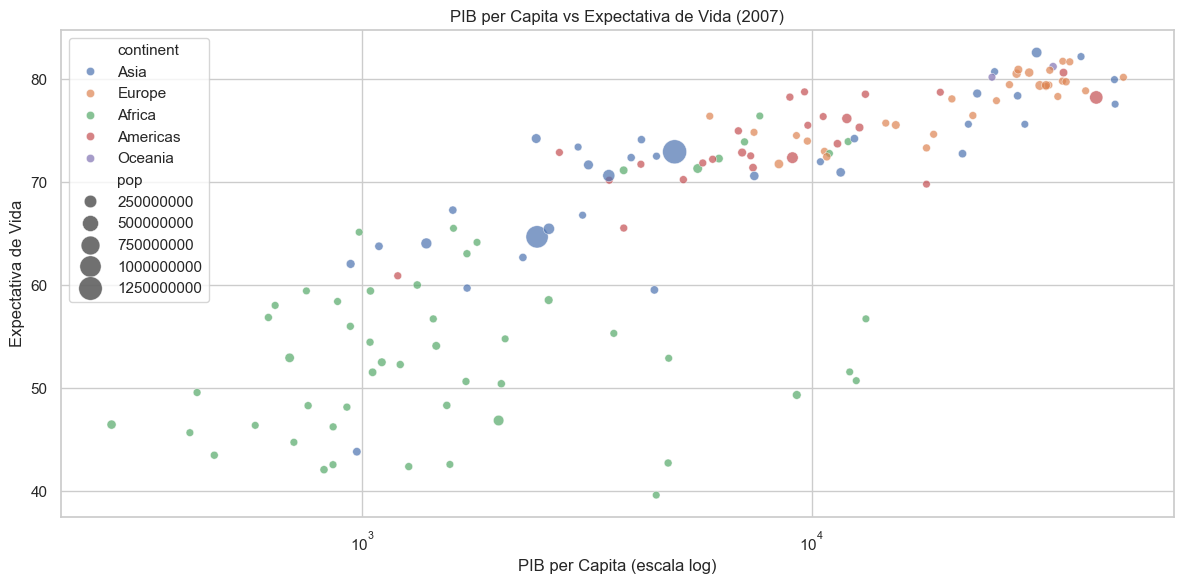

In [14]:
df_2007 = df_gapminder[df_gapminder["year"] == 2007]

ChartUtils.scatter_plot(
    data=df_2007,
    x="gdpPercap",
    y="lifeExp",
    hue="continent",
    size="pop",
    log_x=True,
    title="PIB per Capita vs Expectativa de Vida (2007)",
    xlabel="PIB per Capita (escala log)",
    ylabel="Expectativa de Vida"
)

<font color="#0D9DF0"><h5><b>2.2 - Evolução do PIB por continente</b></h5></font> 
Observa-se crescimento do PIB per capita médio em todos os continentes ao longo do período analisado. Europa e Oceania mantêm os maiores níveis econômicos médios durante praticamente toda a série histórica. Ásia e Américas apresentam trajetórias de crescimento relativamente semelhantes nas últimas décadas, enquanto a África demonstra evolução mais lenta, evidenciando persistência de desigualdades econômicas globais.

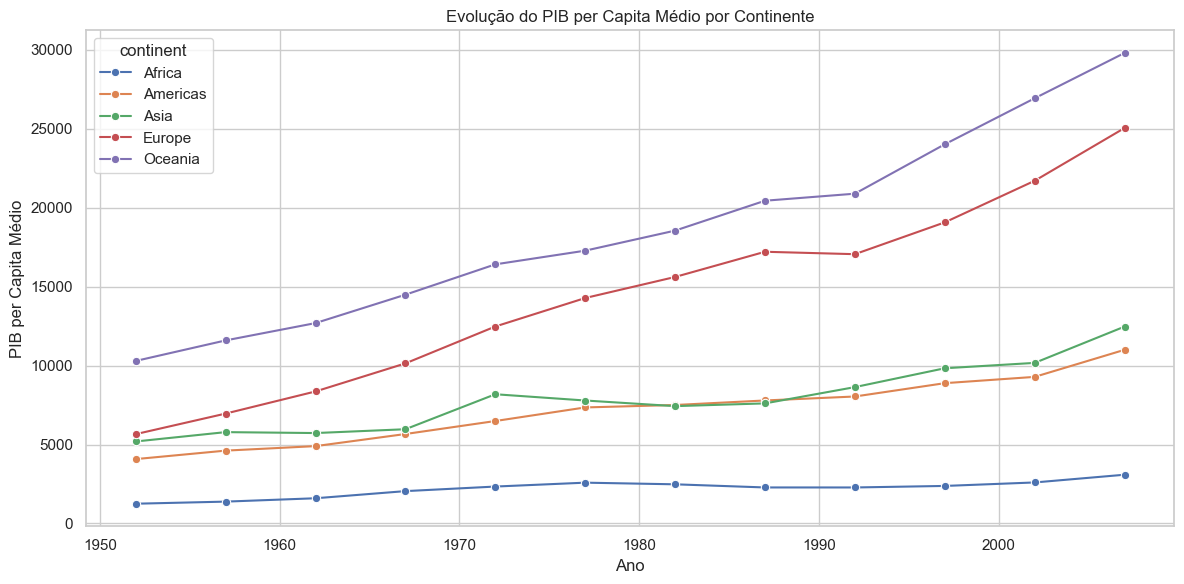

In [15]:
pib_continente = (
    df_gapminder.groupby(["year", "continent"])["gdpPercap"]
    .mean()
    .reset_index()
)

ChartUtils.line_plot(
    data=pib_continente,
    x="year",
    y="gdpPercap",
    hue="continent",
    title="Evolução do PIB per Capita Médio por Continente",
    xlabel="Ano",
    ylabel="PIB per Capita Médio"
)

<font color="#0D9DF0"><h5><b>2.3 - Outliers</b></h5></font> 
Os países identificados como outliers apresentam níveis relativamente elevados de PIB per capita, mas expectativa de vida abaixo do padrão observado para economias de renda semelhante. Muitos desses países possuem economias dependentes de recursos naturais, especialmente petróleo e mineração, além de apresentarem elevada desigualdade social, concentração de renda ou desafios estruturais em saúde pública. Esses resultados evidenciam que crescimento econômico isoladamente não garante melhoria proporcional na qualidade de vida da população.

#### Muitos desses países compartilham características como:
    desigualdade social elevada
    dependência de petróleo/gás/mineração
    concentração de renda
    desenvolvimento econômico pouco distribuído
    problemas estruturais em saúde pública
    histórico político instável ou desenvolvimento tardio

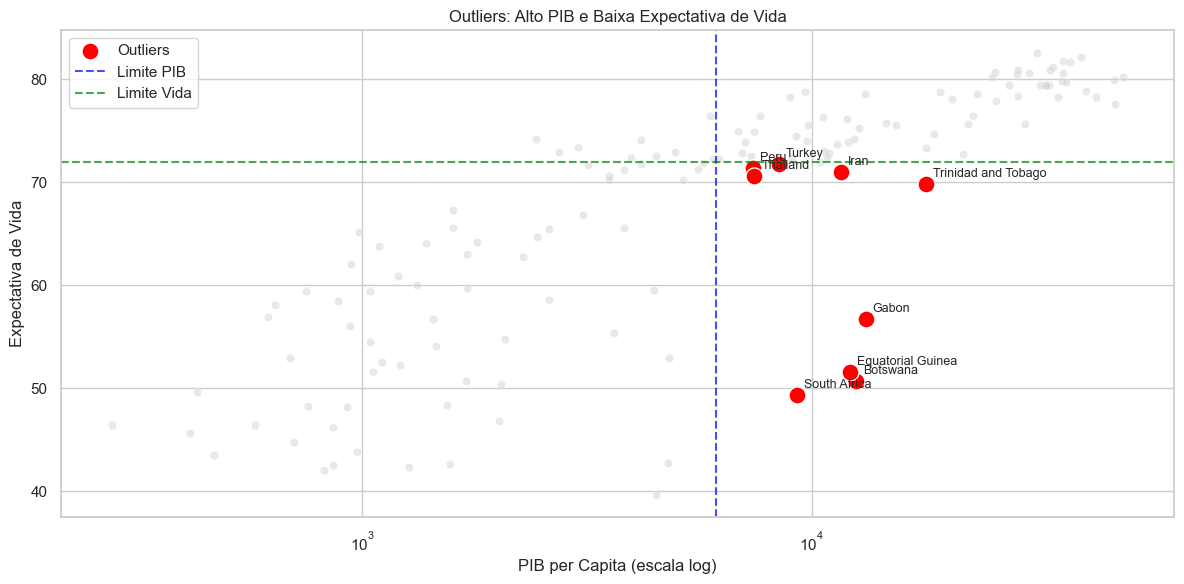

In [16]:
df_2007 = df_gapminder[df_gapminder["year"] == 2007]

# Limites
pib_alto = df_2007["gdpPercap"].median()
vida_baixa = df_2007["lifeExp"].median()

# Outliers
outliers = df_2007[
    (df_2007["gdpPercap"] > pib_alto) &
    (df_2007["lifeExp"] < vida_baixa)
]

ChartUtils.outlier_scatter_plot(
    data=df_2007,
    outliers=outliers,
    x="gdpPercap",
    y="lifeExp",
    label_col="country",
    vline=pib_alto,
    hline=vida_baixa,
    log_x=True,
    title="Outliers: Alto PIB e Baixa Expectativa de Vida",
    xlabel="PIB per Capita (escala log)",
    ylabel="Expectativa de Vida"
)


<font color="#0D9DF0"><h4><b>BLOCO 3 — População e Distribuição</b></h4></font> 
<font color="#0D9DF0"><h5><b>3.1 - Top 10 países mais populoso</b></h5></font> 
Observa-se forte concentração da população mundial em poucos países, especialmente na Ásia. China e Índia lideram amplamente o ranking populacional em 2007, refletindo o elevado peso demográfico do continente asiático na população global. Países como Estados Unidos, Indonésia e Brasil também apresentam grande relevância populacional.

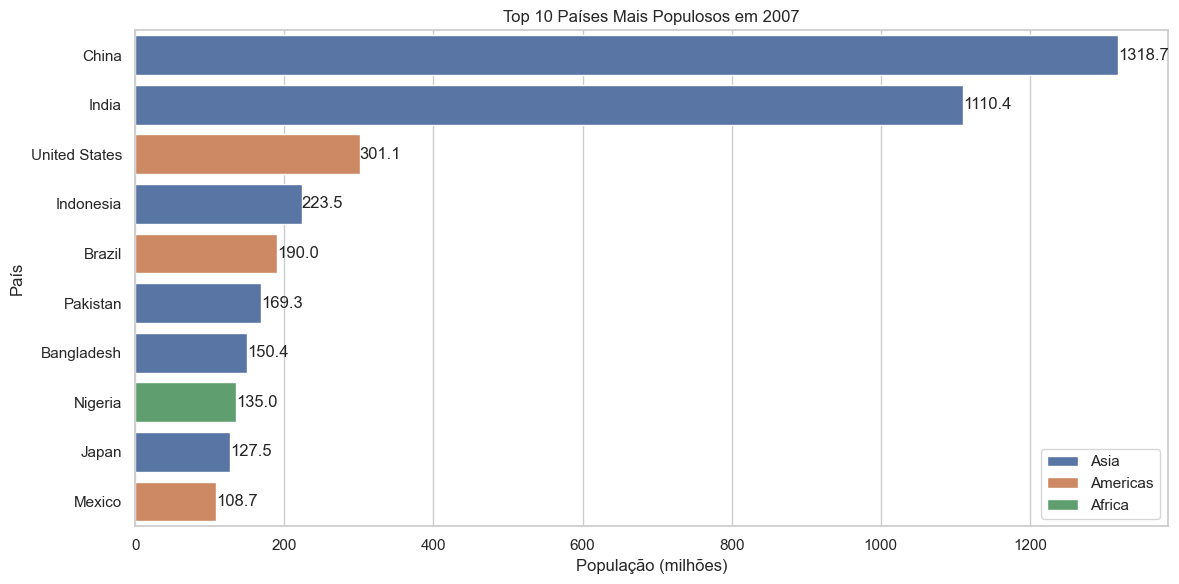

In [17]:
df_top_10_paises_2007 = df_gapminder[df_gapminder["year"] == 2007]
df_top_10_paises_2007 = (
    df_top_10_paises_2007.assign(pop_milhoes=df_top_10_paises_2007["pop"] / 1_000_000)
    .sort_values(by="pop", ascending=False)
    .head(10)
)
ChartUtils.bar_plot(
    data=df_top_10_paises_2007,
    x="pop_milhoes",
    y="country",
    hue="continent",
    title="Top 10 Países Mais Populosos em 2007",
    xlabel="População (milhões)",
    ylabel="País",
    value_format="%.1f"
)

<font color="#0D9DF0"><h5><b>3.2 - Evolução da Ásia vs Europa</b></h5></font> 
Observa-se crescimento populacional expressivo da Ásia ao longo das décadas, contrastando com a relativa estabilidade populacional da Europa. Esse comportamento reflete diferenças em taxas de natalidade, urbanização, desenvolvimento econômico e transição demográfica entre os continentes.

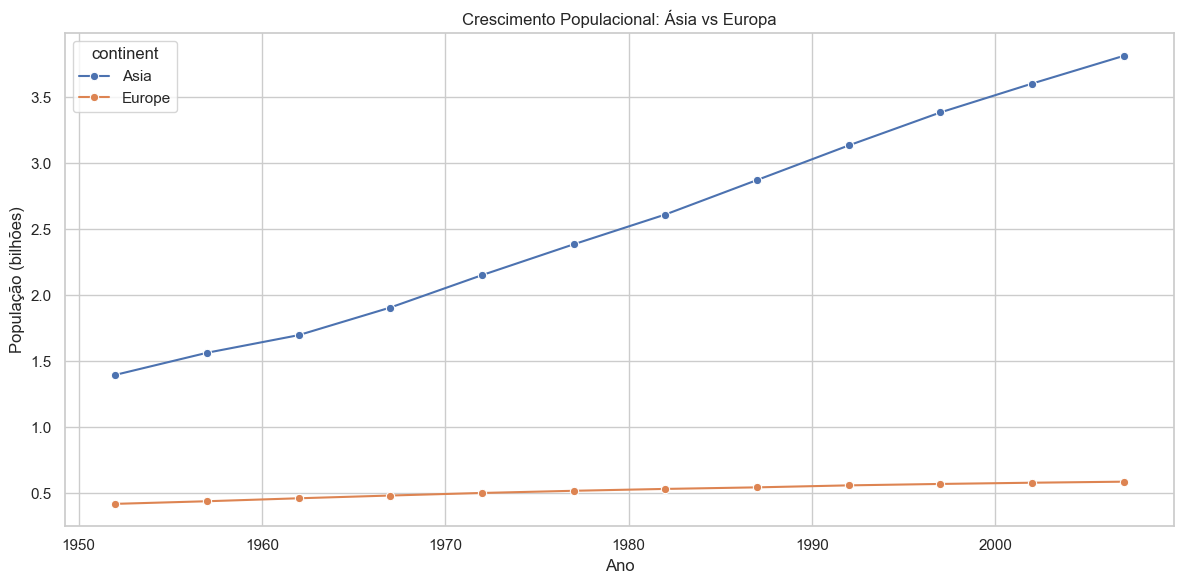

In [18]:
pop_continente = (
    df_gapminder.groupby(["year", "continent"])["pop"]
    .sum()
    .reset_index()
)

asia_europa = pop_continente[
    pop_continente["continent"].isin(["Asia", "Europe"])
]

asia_europa["pop_bilhoes"] = (
    asia_europa["pop"] / 1_000_000_000
)

ChartUtils.line_plot(
    data=asia_europa,
    x="year",
    y="pop_bilhoes",
    hue="continent",
    title="Crescimento Populacional: Ásia vs Europa",
    xlabel="Ano",
    ylabel="População (bilhões)"
)

<font color="#0D9DF0"><h5><b>3.3 - Área empilhada — População mundial por continente</b></h5></font> 
A visualização evidencia a forte concentração populacional mundial na Ásia ao longo de todo o período analisado. Também é possível observar o crescimento progressivo da participação africana na população global, enquanto a Europa apresenta crescimento relativamente estável. O gráfico destaca importantes transformações demográficas globais ao longo das décadas.

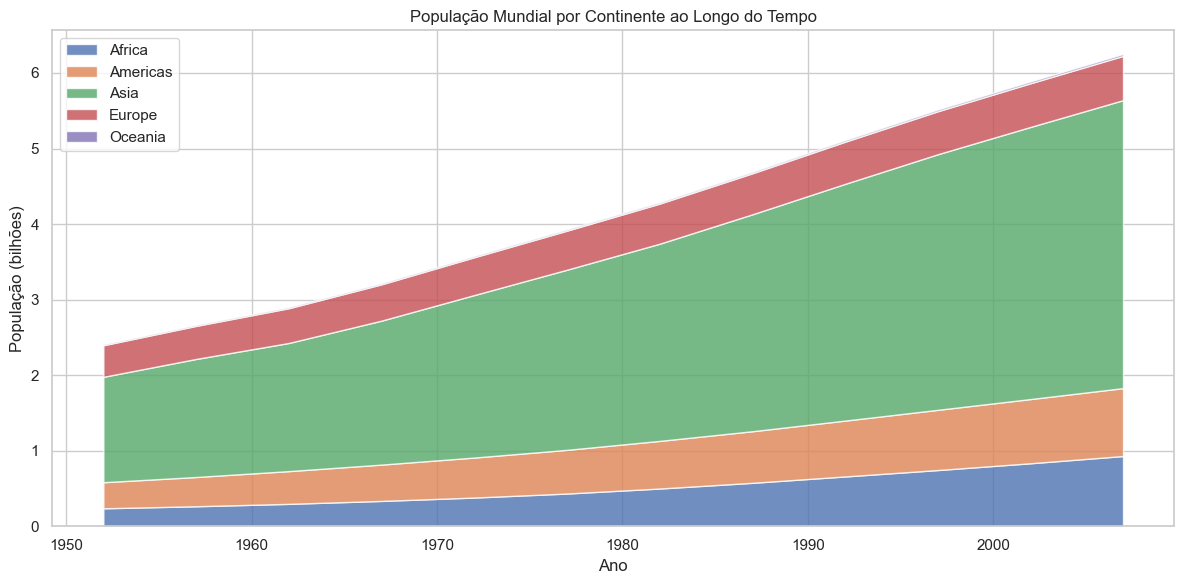

In [19]:
pop_continente = (
    df_gapminder.groupby(["year", "continent"])["pop"]
    .sum()
    .reset_index()
)
pivot_pop = pop_continente.pivot(
    index="year",
    columns="continent",
    values="pop"
)
pivot_pop = pivot_pop / 1_000_000_000
ChartUtils.stack_plot(
    data=pivot_pop,
    x=pivot_pop.index,
    title="População Mundial por Continente ao Longo do Tempo",
    xlabel="Ano",
    ylabel="População (bilhões)"
)

<font color="#0D9DF0"><h4><b>BLOCO 4 — Comparações Regionais</b></h4></font> 
<font color="#0D9DF0"><h5><b>4.1 - Boxplot por continente</b></h5></font>
Observa-se significativa desigualdade regional na expectativa de vida em 2007. África apresenta a menor mediana e maior variabilidade relativa, enquanto Europa e Oceania concentram os maiores valores de longevidade. Os resultados evidenciam diferenças históricas e socioeconômicas entre os continentes em relação ao acesso à saúde, saneamento e qualidade de vida. 

/Users/leonwagnerfariasdesouza/projeto_final_python_ciencia_dados/src/charts.py:530: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


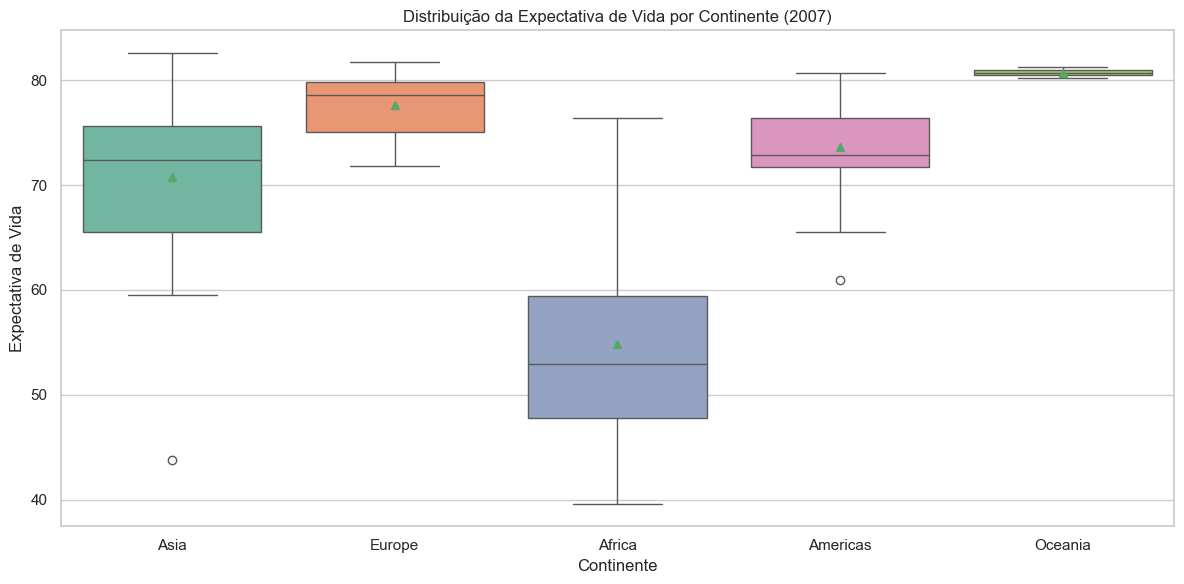

In [20]:
df_2007 = df_gapminder[df_gapminder["year"] == 2007]

ChartUtils.box_plot(
    data=df_2007,
    x="continent",
    y="lifeExp",
    title="Distribuição da Expectativa de Vida por Continente (2007)",
    xlabel="Continente",
    ylabel="Expectativa de Vida",
    showmeans=True
)


<font color="#0D9DF0"><h5><b>4.2 - Brasil vs América do Sul</b></h5></font>
Observa-se crescimento contínuo da expectativa de vida no Brasil ao longo do período analisado, acompanhando a tendência geral da América do Sul. O país apresenta trajetória próxima da média regional, refletindo melhorias graduais em saúde pública, saneamento e condições socioeconômicas nas últimas décadas.

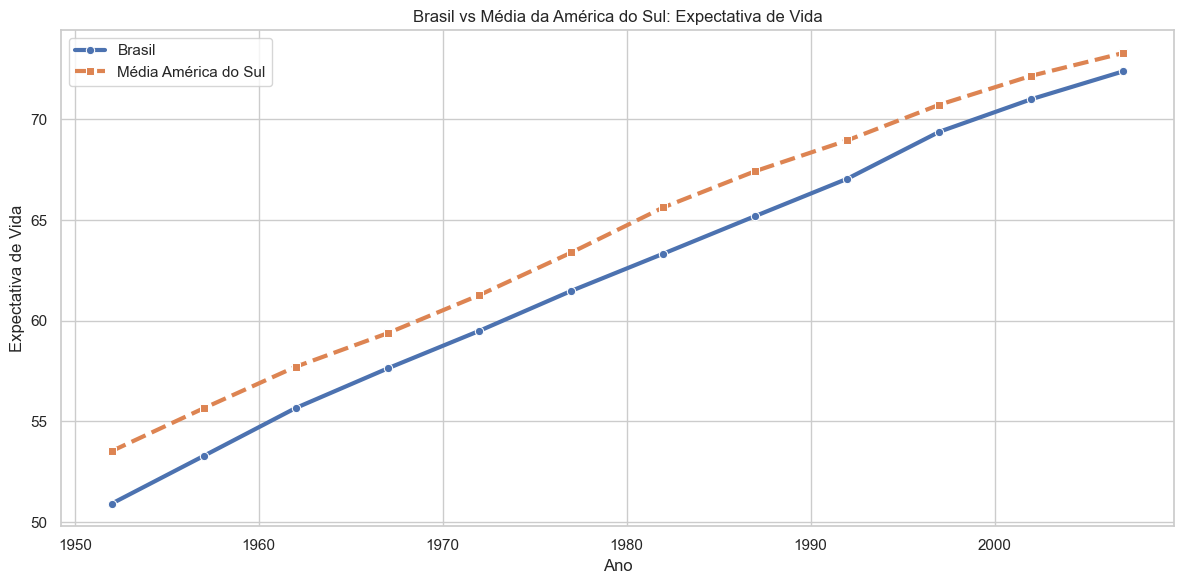

In [21]:
brasil = df_gapminder[df_gapminder["country"] == "Brazil"]
paises_america_sul = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Chile",
    "Colombia",
    "Ecuador",
    "Paraguay",
    "Peru",
    "Uruguay",
    "Venezuela"
]

america_sul = df_gapminder[
    df_gapminder["country"].isin(paises_america_sul)
]

media_america_sul = (
    america_sul.groupby("year")["lifeExp"]
    .mean()
    .reset_index()
)

ChartUtils.compare_line_plot(
    data1=brasil,
    data2=media_america_sul,
    x="year",
    y="lifeExp",
    label1="Brasil",
    label2="Média América do Sul",
    title="Brasil vs Média da América do Sul: Expectativa de Vida",
    xlabel="Ano",
    ylabel="Expectativa de Vida",
    marker1="o",
    marker2="s",
    linestyle1="-",
    linestyle2="--"
)



<font color="#0D9DF0"><h4><b>BLOCO 5 — Relações Estatísticas</b></h4></font> 
<font color="#0D9DF0"><h5><b>5.1 - População vs PIB per capita</b></h5></font>
Observa-se que países mais populosos não são necessariamente os mais ricos em termos de PIB per capita. A visualização evidencia grande dispersão entre população e riqueza média, indicando que fatores econômicos, históricos e estruturais influenciam o desenvolvimento econômico além do tamanho populacional.

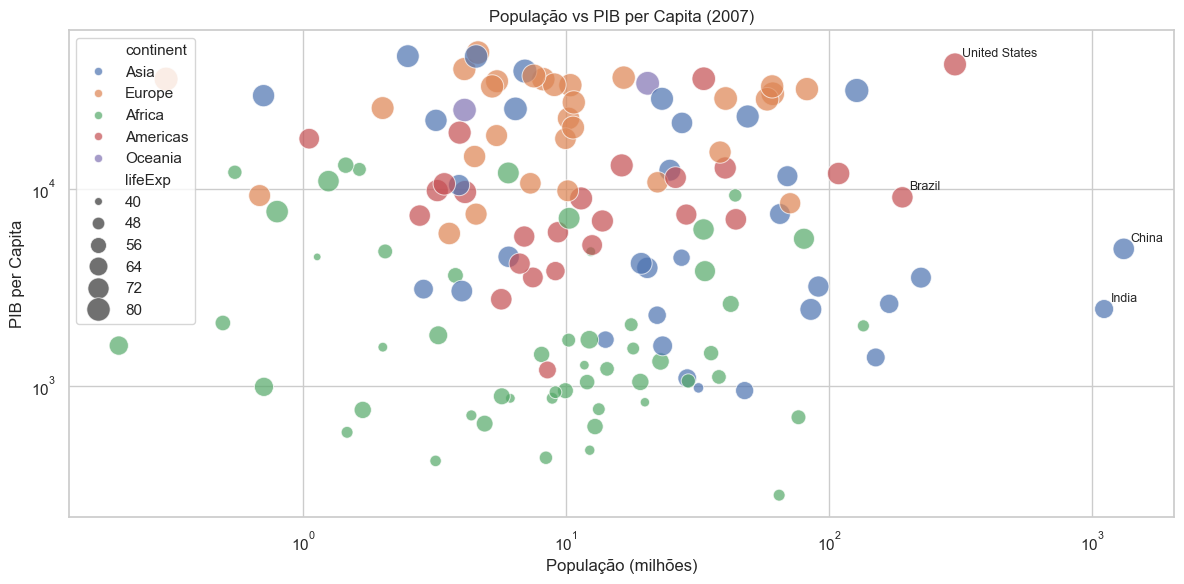

In [22]:
df_2007 = df_gapminder[df_gapminder["year"] == 2007]
df_2007["pop_milhoes"] = df_2007["pop"] / 1_000_000

destaques = df_2007[
    df_2007["country"].isin(
        ["China", "India", "United States", "Brazil"]
    )
]

ChartUtils.scatter_plot(
    data=df_2007,
    x="pop_milhoes",
    y="gdpPercap",
    hue="continent",
    size="lifeExp",
    log_x=True,
    log_y=True,
    title="População vs PIB per Capita (2007)",
    xlabel="População (milhões)",
    ylabel="PIB per Capita",
    label_data=destaques,
    label_col="country"
)

<font color="#0D9DF0"><h5><b>5.2 - Heatmap de correlação</b></h5></font>
O heatmap evidencia correlação positiva entre PIB per capita e expectativa de vida, indicando que países economicamente mais desenvolvidos tendem a apresentar melhores indicadores de longevidade. Por outro lado, a população apresenta correlação fraca com as demais variáveis, sugerindo que o tamanho populacional, isoladamente, não determina riqueza média nem qualidade de vida.

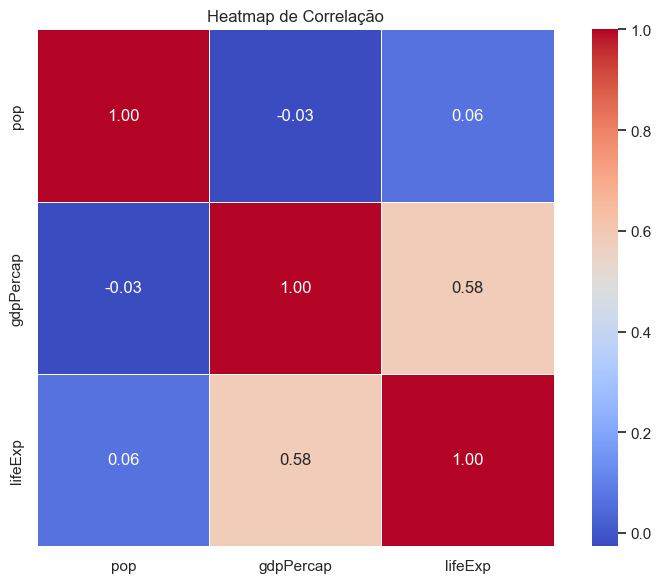

In [23]:
corr = df_gapminder[["pop", "gdpPercap", "lifeExp"]].corr()

ChartUtils.heatmap_plot(
    data=corr,
    title="Heatmap de Correlação"
)

<font color="#0D9DF0"><h4><b>BLOCO 6 — Evolução Histórica</b></h4></font> 
<font color="#0D9DF0"><h5><b>6.1 - Maior aumento percentual de expectativa de vida</b></h5></font>
Alguns países apresentaram crescimento expressivo da expectativa de vida entre 1952 e 2007, refletindo avanços em saúde pública, vacinação, saneamento básico e desenvolvimento socioeconômico. Em muitos casos, os maiores aumentos ocorreram em países que inicialmente possuíam indicadores muito baixos, permitindo ganhos relativos mais significativos ao longo das décadas.

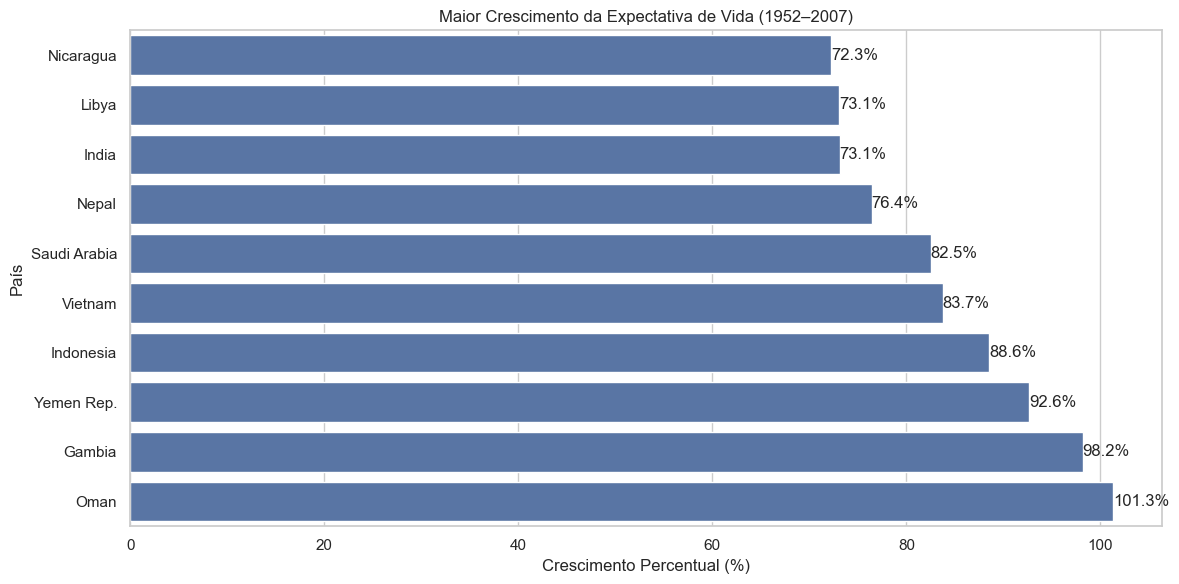

In [24]:
life_1952 = df_gapminder[df_gapminder["year"] == 1952][
    ["country", "lifeExp"]
]

life_2007 = df_gapminder[df_gapminder["year"] == 2007][
    ["country", "lifeExp"]
]

life_1952 = life_1952.rename(
    columns={"lifeExp": "lifeExp_1952"}
)

life_2007 = life_2007.rename(
    columns={"lifeExp": "lifeExp_2007"}
)

crescimento = pd.merge(
    life_1952,
    life_2007,
    on="country"
)

crescimento["crescimento_percentual"] = (
    (
        crescimento["lifeExp_2007"] -
        crescimento["lifeExp_1952"]
    )
    / crescimento["lifeExp_1952"]
) * 100

top_crescimento = crescimento.sort_values(
    by="crescimento_percentual",
    ascending=False
)

# top_crescimento.head(10)
# Top 10
top_10 = top_crescimento.head(10)

# Ordenar para gráfico
top_10 = top_10.sort_values(
    by="crescimento_percentual"
)

ChartUtils.bar_plot(
    data=top_10,
    x="crescimento_percentual",
    y="country",
    title="Maior Crescimento da Expectativa de Vida (1952–2007)",
    xlabel="Crescimento Percentual (%)",
    ylabel="País",
    value_format="%.1f%%",
    legend=False
)


<font color="#0D9DF0"><h4><b>Seção Extra: Educação, Renda e Qualidade de Vida</b></h4></font> 

Como complemento às análises anteriores, foi incorporado ao estudo o indicador *Expected Years of Schooling* (anos esperados de escolaridade), extraído da base de dados da UNDP para o ano de 2007. A inclusão desse indicador permite adicionar uma nova dimensão à análise, investigando como a educação se relaciona com variáveis já presentes na base Gapminder, como renda per capita e expectativa de vida. Dessa forma, torna-se possível observar não apenas aspectos econômicos e de saúde, mas também o papel da educação como fator associado ao desenvolvimento humano.

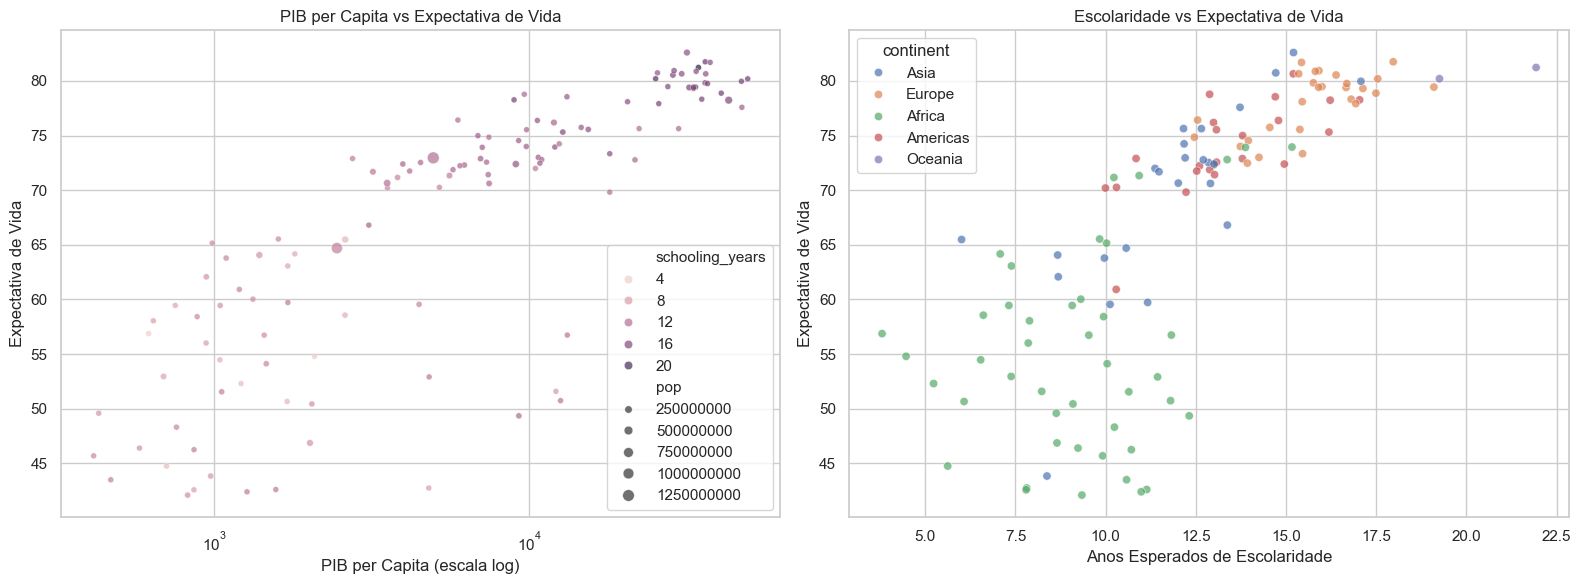

In [25]:
# Carregando os dados
df_hdi = pd.read_csv('../data/raw/hdr-data.csv', sep=',', encoding='utf-8')

df_extra = prepare_schooling_data(
    df_gapminder,
    df_hdi
)

ChartUtils.schooling_analysis_subplot(
    data=df_extra
)

<font color="#0D9DF0"><h4><b>Seção Extra: Insight</b></h4></font> 

A análise mostra que países com maior expectativa de escolaridade tendem a concentrar-se em níveis mais elevados de expectativa de vida, indicando uma forte associação entre educação e qualidade de vida. No gráfico econômico, também é possível observar que países mais ricos frequentemente apresentam melhores indicadores educacionais, embora existam diferenças regionais que mostram que renda, isoladamente, não explica todo o desenvolvimento humano.